# Statistical Evidence — what survives proper controls

**Author:** Namık Akman  
**Goal:** Stress-test the descriptive findings from notebooks 01-05 with inferential statistics. Group averages and bar charts are useful for storytelling, but they can mislead — a finding that looks strong in raw comparisons sometimes evaporates once you control for other variables. This notebook runs two regressions over the per-customer dataset and reports which patterns hold up.

## Models

1. **Linear regression on lifetime revenue (LTV)** — what independently moves the dollar number?
2. **Logistic regression on churn** (binary outcome) — what independently moves the odds of leaving?

Both use the same 9–10 predictor set: tenure, seats, plan tier (dummies vs Basic baseline), referral source (dummies vs event baseline), annual-billing dummy, DevTools-industry dummy, upgrade count, and (for the logit) ticket count.

## 1. Build the per-account dataset

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

DATA = Path(r'C:\Users\Lenovo\OneDrive\Creative\Churn Study\data')

BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE = '#2F9BFF', '#19C37D', '#FF6500'
BG_DARK, FG_LIGHT = '#0F1419', '#E6EDF3'
plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_DARK, 'savefig.facecolor': BG_DARK,
    'axes.edgecolor': FG_LIGHT, 'axes.labelcolor': FG_LIGHT,
    'xtick.color': FG_LIGHT, 'ytick.color': FG_LIGHT, 'text.color': FG_LIGHT,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

accounts = pd.read_csv(DATA / 'ravenstack_accounts.csv', parse_dates=['signup_date'])
subs = pd.read_csv(DATA / 'ravenstack_subscriptions.csv', parse_dates=['start_date','end_date'])
tickets = pd.read_csv(DATA / 'ravenstack_support_tickets.csv', parse_dates=['submitted_at'])
churn_events = pd.read_csv(DATA / 'ravenstack_churn_events.csv', parse_dates=['churn_date'])
obs_end = pd.Timestamp('2024-12-31')

real_churns = churn_events[~churn_events['is_reactivation'].astype(bool)]
last_churn = real_churns.groupby('account_id')['churn_date'].max().rename('last_churn_date')
acc = accounts.merge(last_churn, on='account_id', how='left')
acc['exit_date'] = pd.to_datetime(np.where(acc['churn_flag'], acc['last_churn_date'].fillna(obs_end), obs_end))

subs = subs.sort_values(['account_id','start_date']).reset_index(drop=True)
subs = subs.merge(acc[['account_id','exit_date']], on='account_id', how='left')
subs['next_start'] = subs.groupby('account_id')['start_date'].shift(-1)
subs['effective_end'] = subs[['end_date','next_start','exit_date']].min(axis=1)
subs['effective_end'] = subs[['effective_end','exit_date']].min(axis=1)
subs['duration_months'] = ((subs['effective_end'] - subs['start_date']).dt.days / 30).clip(lower=0)
subs['revenue'] = subs['mrr_amount'] * subs['duration_months']

def first_plan(g): return g.sort_values('start_date').iloc[0]['plan_tier']

per_acc = subs.groupby('account_id').agg(
    total_revenue=('revenue','sum'),
    n_subscriptions=('subscription_id','count'),
    n_upgrades=('upgrade_flag','sum'),
    tenure_months=('duration_months','sum'),
).reset_index()
per_acc['landing_plan'] = subs.groupby('account_id').apply(first_plan, include_groups=False).reset_index(drop=True).values
per_acc = per_acc.merge(accounts[['account_id','referral_source','industry','country','churn_flag','seats']], on='account_id', how='left')
per_acc['billing'] = (subs.groupby('account_id')['billing_frequency']
                     .agg(lambda s: s.mode().iloc[0]).reset_index(drop=True).values)
per_acc['n_tickets'] = per_acc['account_id'].map(tickets.groupby('account_id').size()).fillna(0).astype(int)

# Dummies
per_acc['is_partner']         = (per_acc['referral_source'] == 'partner').astype(int)
per_acc['is_organic']         = (per_acc['referral_source'] == 'organic').astype(int)
per_acc['is_pro_land']        = (per_acc['landing_plan'] == 'Pro').astype(int)
per_acc['is_enterprise_land'] = (per_acc['landing_plan'] == 'Enterprise').astype(int)
per_acc['is_annual']          = (per_acc['billing'] == 'annual').astype(int)
per_acc['is_devtools']        = (per_acc['industry'] == 'DevTools').astype(int)
per_acc['churn']              = per_acc['churn_flag'].astype(int)

print(f'Accounts: {len(per_acc)}  | Churned: {per_acc["churn"].sum()}')

Accounts: 500  | Churned: 110


## 2. Correlation matrix — the bivariate view

Before any model, look at the pairwise correlations between the numeric features. This is the simplest possible "what moves with what" view.

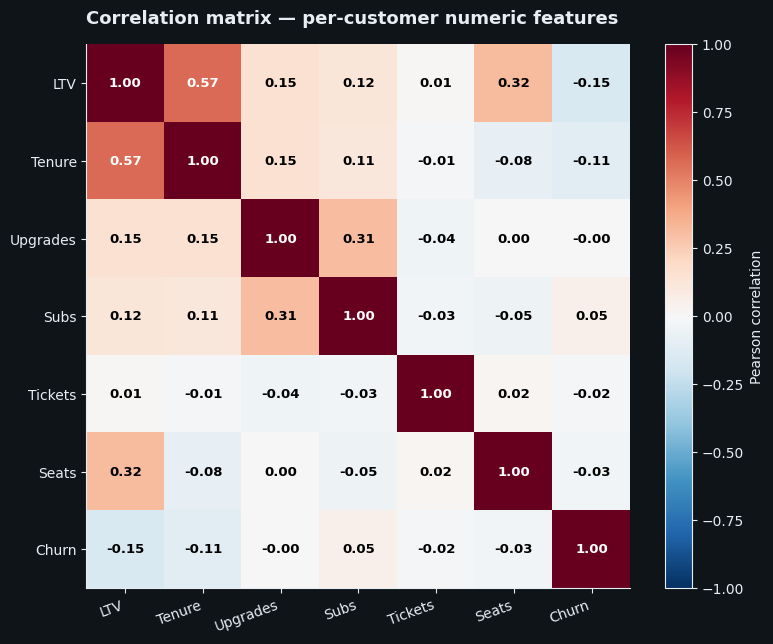

,total_revenue,tenure_months,n_upgrades,n_subscriptions,n_tickets,seats,churn
total_revenue,1.00,0.57,0.15,0.12,0.01,0.32,-0.15
tenure_months,0.57,1.00,0.15,0.11,-0.01,-0.08,-0.11
n_upgrades,0.15,0.15,1.00,0.31,-0.04,0.00,-0.00
n_subscriptions,0.12,0.11,0.31,1.00,-0.03,-0.05,0.05
n_tickets,0.01,-0.01,-0.04,-0.03,1.00,0.02,-0.02
seats,0.32,-0.08,0.00,-0.05,0.02,1.00,-0.03
churn,-0.15,-0.11,-0.00,0.05,-0.02,-0.03,1.00


In [2]:
numeric_cols = ['total_revenue','tenure_months','n_upgrades','n_subscriptions','n_tickets','seats','churn']
corr = per_acc[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
labels = ['LTV','Tenure','Upgrades','Subs','Tickets','Seats','Churn']
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_title('Correlation matrix — per-customer numeric features', loc='left', pad=15)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='black' if abs(v) < 0.5 else 'white', fontsize=9.5, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='Pearson correlation')
cbar.ax.yaxis.label.set_color(FG_LIGHT); cbar.ax.tick_params(colors=FG_LIGHT)
plt.tight_layout(); plt.show()
corr

**Read:**

- **LTV is anchored by tenure (r = 0.57) and seats (r = 0.32).** Everything else is sideshow at the bivariate level.
- **Support tickets correlate with essentially nothing** (|r| ≤ 0.04 across the board). The null finding from notebook 04 reproduces here under a different method.
- **Churn is only weakly correlated with anything numeric** (max |r| = 0.15 with LTV). Predicting churn requires interactions and categorical effects — a single number won't do it.

## 3. Linear regression on LTV — what moves the dollar number?

In [3]:
features_ltv = ['tenure_months','n_upgrades',
                'is_partner','is_organic',
                'is_pro_land','is_enterprise_land',
                'is_annual','is_devtools','seats']
X = sm.add_constant(per_acc[features_ltv].astype(float))
y = per_acc['total_revenue'].astype(float)
ols = sm.OLS(y, X).fit()
print(f'R-squared: {ols.rsquared:.3f}  |  Adj R-squared: {ols.rsquared_adj:.3f}  |  N: {int(ols.nobs)}')
ols.summary().tables[1]

R-squared: 0.482  |  Adj R-squared: 0.473  |  N: 500


,coef,std err,t,P>|t|,[0.025,0.975]
const,-1.391e+04,2411.798,-5.767,0.000,-1.86e+04,-9170.453
tenure_months,2274.8123,125.400,18.140,0.000,2028.424,2521.201
n_upgrades,1101.0796,730.465,1.507,0.132,-334.150,2536.309
is_partner,2539.6704,2100.531,1.209,0.227,-1587.489,6666.830
is_organic,3523.2802,1940.817,1.815,0.070,-290.070,7336.631
is_pro_land,551.2590,1931.440,0.285,0.775,-3243.668,4346.186
is_enterprise_land,4405.2744,1909.230,2.307,0.021,653.986,8156.563
is_annual,2652.5194,1571.341,1.688,0.092,-434.878,5739.916
is_devtools,-1092.3572,1873.087,-0.583,0.560,-4772.630,2587.915
seats,421.1273,37.132,11.341,0.000,348.169,494.086


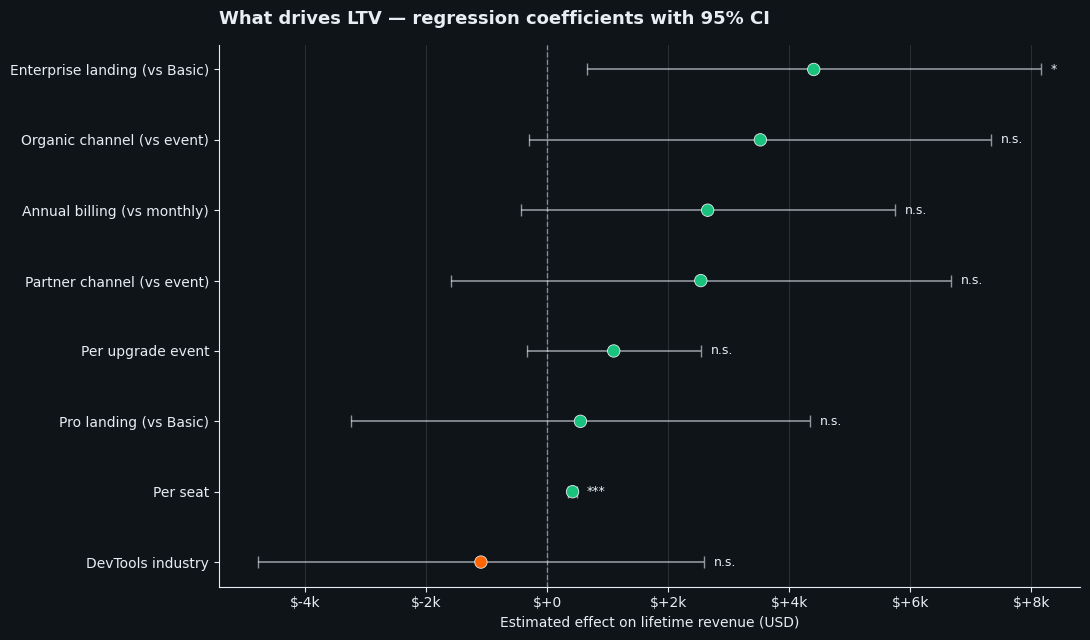

In [4]:
plot_vars = {
    'n_upgrades':         'Per upgrade event',
    'is_partner':         'Partner channel (vs event)',
    'is_organic':         'Organic channel (vs event)',
    'is_pro_land':        'Pro landing (vs Basic)',
    'is_enterprise_land': 'Enterprise landing (vs Basic)',
    'is_annual':          'Annual billing (vs monthly)',
    'is_devtools':        'DevTools industry',
    'seats':              'Per seat',
}
plot_df = pd.DataFrame({
    'label': [plot_vars[v] for v in plot_vars],
    'coef':  [ols.params[v] for v in plot_vars],
    'ci_lo': [ols.conf_int().loc[v, 0] for v in plot_vars],
    'ci_hi': [ols.conf_int().loc[v, 1] for v in plot_vars],
    'p':     [ols.pvalues[v] for v in plot_vars],
}).sort_values('coef')

fig, ax = plt.subplots(figsize=(11, 6.5))
y_pos = np.arange(len(plot_df))
colors = [BRAND_GREEN if c > 0 else BRAND_ORANGE for c in plot_df['coef']]
ax.errorbar(plot_df['coef'], y_pos,
            xerr=[plot_df['coef'] - plot_df['ci_lo'], plot_df['ci_hi'] - plot_df['coef']],
            fmt='none', ecolor=FG_LIGHT, capsize=4, linewidth=1.2, alpha=0.6)
ax.scatter(plot_df['coef'], y_pos, s=80, c=colors, edgecolors=FG_LIGHT, linewidth=0.6, zorder=3)
ax.axvline(0, color=FG_LIGHT, linestyle='--', linewidth=1, alpha=0.5)
ax.set_yticks(y_pos); ax.set_yticklabels(plot_df['label'])
ax.set_xlabel('Estimated effect on lifetime revenue (USD)')
ax.set_title('What drives LTV — regression coefficients with 95% CI', loc='left', pad=15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:+.0f}k' if abs(x) >= 1000 else f'${x:+.0f}'))
ax.grid(True, axis='x', alpha=0.12, color=FG_LIGHT)
for i, row in plot_df.reset_index(drop=True).iterrows():
    p_label = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else 'n.s.'))
    ax.text(row['ci_hi'] + max(plot_df['ci_hi']) * 0.02, i,
            p_label, va='center', color=FG_LIGHT, fontsize=9)
plt.tight_layout(); plt.show()

**Read — what survives the regression:**

- **Tenure: +$2,275 per month (p < 0.001).** Dominant LTV mechanic. Omitted from the forest plot because it would dwarf the x-axis.
- **Seats: +$421 per seat (p < 0.001).** Single most reliable non-tenure predictor — bigger orgs earn proportionally more.
- **Enterprise landing: +$4,405 vs Basic (p = 0.02).** A real premium after controlling for tenure, seats, and channel. The only landing-plan effect that survives controls.
- Organic channel (+$3,523, p = 0.07) and annual billing (+$2,653, p = 0.09) — directionally positive but not significant at p < 0.05 with N = 500.
- **Per-upgrade event: +$1,101 but not significant** (p = 0.13). This is the honest caveat: the bar-chart story "Basic-upgraders earn $24k vs $13k for Basic-only" is real, but a big chunk of that gap is a tenure effect (upgraders also stay longer), not a pure upgrade effect.
- Pro landing, partner channel, DevTools industry: **not significant** for LTV after controls.

## 4. Logistic regression on churn — what moves the odds of leaving?

In [5]:
features_churn = ['tenure_months',
                  'is_partner','is_organic',
                  'is_pro_land','is_enterprise_land',
                  'is_annual','is_devtools','seats','n_tickets']
X2 = sm.add_constant(per_acc[features_churn].astype(float))
y2 = per_acc['churn'].astype(int)
logit = sm.Logit(y2, X2).fit(disp=False)

odds = pd.DataFrame({
    'coef': logit.params,
    'odds_ratio': np.exp(logit.params),
    'CI_low': np.exp(logit.conf_int()[0]),
    'CI_high': np.exp(logit.conf_int()[1]),
    'p_value': logit.pvalues,
}).round(3).drop('const')
print(f'Pseudo R-squared: {logit.prsquared:.3f}  |  N: {int(logit.nobs)}')
odds

Pseudo R-squared: 0.042  |  N: 500


,coef,odds_ratio,CI_low,CI_high,p_value
tenure_months,-0.046,0.955,0.921,0.989,0.011
is_partner,-0.684,0.505,0.262,0.971,0.040
is_organic,-0.554,0.574,0.327,1.010,0.054
is_pro_land,-0.136,0.873,0.503,1.513,0.627
is_enterprise_land,0.175,1.191,0.705,2.014,0.514
is_annual,0.039,1.040,0.671,1.611,0.861
is_devtools,0.588,1.801,1.106,2.932,0.018
seats,-0.004,0.996,0.985,1.007,0.453
n_tickets,-0.034,0.966,0.861,1.085,0.562


**Read — three findings hold with statistical force, six fail:**

**Significant predictors of churn:**

| Predictor | Odds ratio | p-value | Interpretation |
| --- | ---:| ---:| --- |
| **Partner channel** (vs event) | **0.51** | **0.040** | ~50% lower odds of churning |
| **DevTools industry** | **1.80** | **0.018** | 80% higher odds of churning |
| Tenure (per month observed) | 0.96 | 0.011 | Survivor bias — long-tenure ≠ churn |

**Not significant — i.e. the data actively says NO signal:**

| Predictor | Odds ratio | p-value | Note |
| --- | ---:| ---:| --- |
| Annual billing | 1.04 | 0.86 | **Confirms the lock-in myth — annual ≠ retention** |
| Support tickets (per ticket) | 0.97 | 0.56 | **Confirms the support null from notebook 04** |
| Plan tier (Pro or Enterprise vs Basic) | 0.87 / 1.19 | 0.63 / 0.51 | **Confirms plan tier doesn't matter** |
| Organisation size (seats) | 1.00 | 0.45 | Size doesn't predict churn |
| Organic channel (vs event) | 0.57 | 0.054 | Marginal — directionally lower |

The standard CRM-dashboard playbook — high tickets, escalations, monthly billing — would flag *none* of the right customers in this dataset. The two levers that actually move churn are **acquisition channel** and **industry fit**.

---
## What this notebook proves

1. **Most of the qualitative findings from notebooks 01-05 hold up under proper statistical controls.** The channel-quality gap, the industry effect, the annual-billing null, the support-ticket null — all confirmed by independent regression evidence.
2. **One finding needs a more careful framing.** The bar-chart "Basic-upgrade premium" is partly a tenure effect; the marginal effect of upgrading alone isn't significant once you control for how long the customer stayed. The operational recommendation (focus on upgrade conversion) still stands, but the mechanism is *upgrades → tenure → LTV* rather than *upgrades → LTV* directly.
3. **Two new findings emerge from the regression:**
   - **Seats** are the strongest non-tenure LTV predictor — proportional pricing on seat count is doing real work.
   - **Enterprise landing** still adds a measurable premium ($4,405) after controlling for tenure and seats, which means the high-end direct sale has some intrinsic value that isn't captured by descriptive averages alone.
4. **R² = 0.48 on 500 customers with 9 predictors.** A meaningful share of LTV variance is explained, but a meaningful share isn't — there's room for product-engagement features (from feature_usage data) to add explanatory power in a follow-up model.